# DISTRIBUCIONES

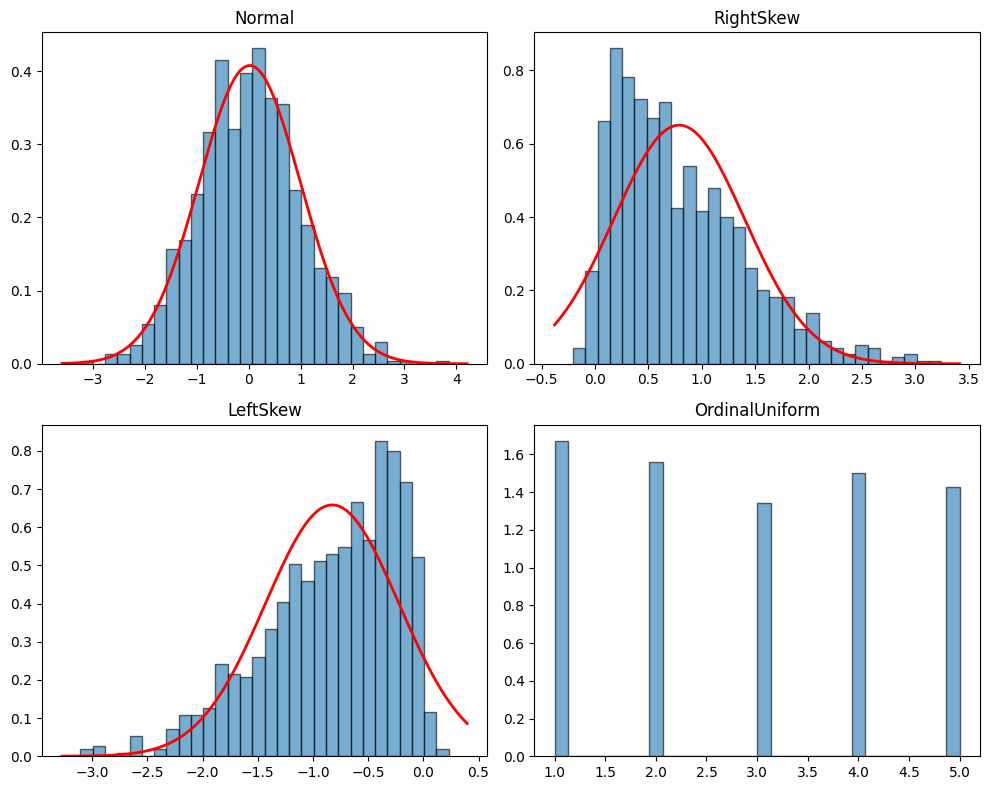

In [23]:
# Datos y gráfico 2×2 con matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skewnorm

# DataFrame con cuatro distribuciones distintas
np.random.seed(42)
df = pd.DataFrame({
    "Normal":          np.random.normal(0, 1, 1000),
    "RightSkew":       skewnorm.rvs(a=10,  size=1000),
    "LeftSkew":        skewnorm.rvs(a=-10, size=1000),
    "OrdinalUniform":  np.random.randint(1, 6, 1000)
})

# Figura 2×2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), df.columns):
    ax.hist(df[col], bins=30, density=True, alpha=0.6, edgecolor="black")
    if col != "OrdinalUniform":               # curva solo para variables continuas
        mu, std = norm.fit(df[col])
        x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
        ax.plot(x, norm.pdf(x, mu, std), "r", linewidth=2)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Qué podríamos hacer con cada variable según su forma

- **Normal**  
  La forma ya es buena. No hace falta transformarla. Solo escalarla si el modelo lo necesita.

- **RightSkew**  
  Tiene muchos valores bajos y pocos altos. Podemos aplicar logaritmo para que tenga una forma más equilibrada. Después, escalar.

- **LeftSkew**  
  Tiene muchos valores altos y pocos bajos. Podemos aplicar alguna transformación (logaritmo o raíz) para mejorar la forma. Después, escalar.

- **OrdinalUniform**  
  Todos los valores aparecen con la misma frecuencia. Puede ser útil crear nuevas columnas a partir de esta. También se puede escalar.

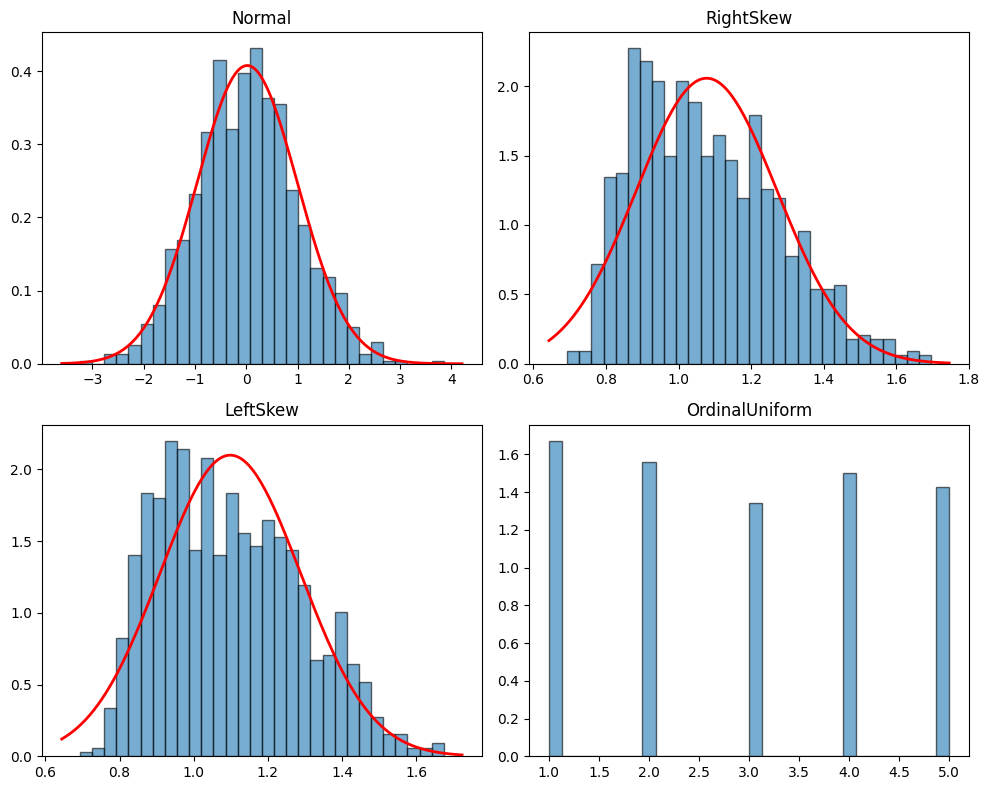

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skewnorm

# Datos originales
np.random.seed(42)
df = pd.DataFrame({
    "Normal":          np.random.normal(0, 1, 1000),
    "RightSkew":       skewnorm.rvs(a=10,  size=1000),
    "LeftSkew":        skewnorm.rvs(a=-10, size=1000),
    "OrdinalUniform":  np.random.randint(1, 6, 1000)
})

# Transformaciones:
# RightSkew → log para reducir sesgo a la derecha
df["RightSkew"] = np.log1p(df["RightSkew"] - df["RightSkew"].min() + 1)

# LeftSkew → log inverso para reducir sesgo a la izquierda
df["LeftSkew"] = np.log1p(df["LeftSkew"].max() - df["LeftSkew"] + 1)

# Gráficos después de transformar
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), df.columns):
    ax.hist(df[col], bins=30, density=True, alpha=0.6, edgecolor="black")
    if col != "OrdinalUniform":
        mu, std = norm.fit(df[col])
        x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
        ax.plot(x, norm.pdf(x, mu, std), "r", linewidth=2)
    ax.set_title(col)
plt.tight_layout()
plt.show()


# OUTLIERS

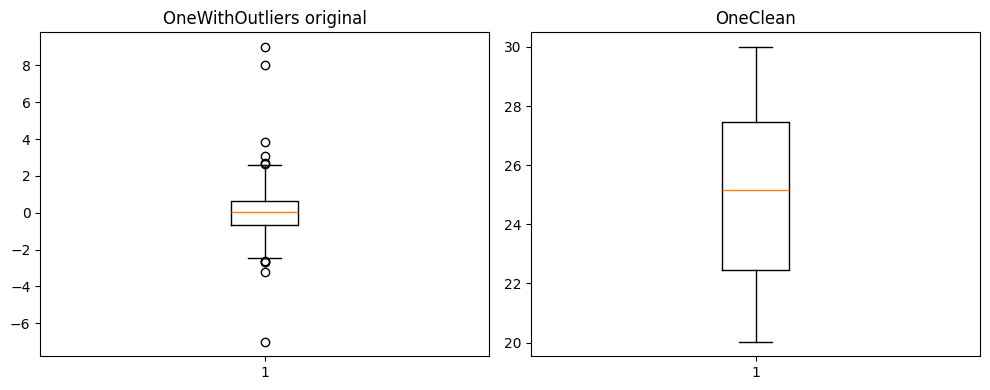

Outliers antes de limpiar: 11


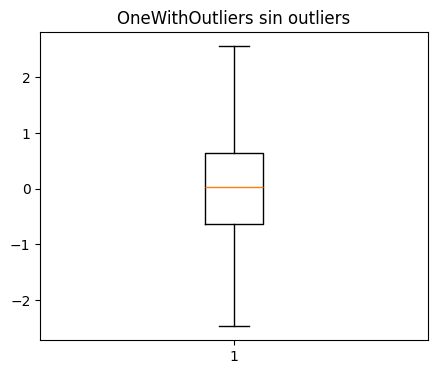

Outliers eliminados: 12


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos: una columna con outliers y otra limpia
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    "OneWithOutliers": np.concatenate([np.random.normal(0, 1, n), [8, 9, -7]]),
     "OneClean":        np.random.uniform(20, 30, n + 3)
})

# Boxplots originales (lado a lado)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(df["OneWithOutliers"])
ax[0].set_title("OneWithOutliers original")
ax[1].boxplot(df["OneClean"])
ax[1].set_title("OneClean")
plt.tight_layout()
plt.show()

q1, q3 = df["OneWithOutliers"].quantile([0.25, 0.75])
iqr = q3 - q1
n_outliers = ((df["OneWithOutliers"] < q1 - 1.5 * iqr) | (df["OneWithOutliers"] > q3 + 1.5 * iqr)).sum()
print(f"Outliers antes de limpiar: {n_outliers}")

# Función: elimina todos los outliers mediante IQR iterativo
def remove_outliers_iqr(s):
    y = s.copy()
    while True:
        q1, q3 = y.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (y >= lower) & (y <= upper)
        if mask.all():
            break
        y = y[mask]
    return y

clean_series = remove_outliers_iqr(df["OneWithOutliers"])


# Boxplot final sin outliers
plt.figure(figsize=(5, 4))
plt.boxplot(clean_series)
plt.title("OneWithOutliers sin outliers")
plt.show()

print(f"Outliers eliminados: {len(df) - len(clean_series)}")

# CORRELACIONES ENTRE CARACTERÍSTICAS

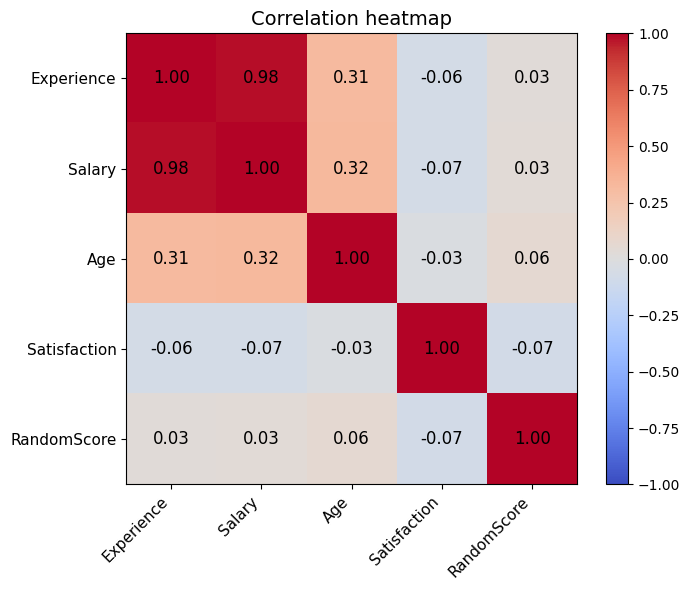

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500
experience = np.random.normal(5, 2, n)  # años de experiencia

df = pd.DataFrame({
    "Experience": experience,
    "Salary": 2000 + experience * 500 + np.random.normal(0, 200, n),              # correlación positiva fuerte
    "Age": experience + np.random.normal(25, 5, n),                               # correlación media
    "Satisfaction": np.clip(-(experience - 5)**2 + 25 + np.random.normal(0, 2, n), 0, 30),  # no lineal
    "RandomScore": np.random.uniform(0, 10, n)                                    # sin correlación
})

# -----------------------------------------
# Matriz de correlación con etiquetas claras
# -----------------------------------------
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Etiquetas en ejes
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(corr.columns, fontsize=11)

# Valores dentro de cada celda
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = f"{corr.iloc[i, j]:.2f}"
        ax.text(j, i, valor, ha='center', va='center', color='black', fontsize=12)

plt.colorbar(cax, fraction=0.046, pad=0.04)
plt.title("Correlation heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# CORRELACIÓN DE CADA CARACTERÍSTICA CON LA VARIABLE OBJECTIVO

In [27]:
import numpy as np
import pandas as pd

# Datos sintéticos
np.random.seed(42)
n = 500
Target = np.random.normal(0, 1, n)                       # variable objetivo
LinearFeature = 3 * Target + np.random.normal(0, 0.2, n) # relación lineal fuerte
NonLinearFeature = Target**2 + np.random.normal(0, 0.5, n)  # relación no lineal

df = pd.DataFrame({
    "Target": Target,
    "LinearFeature": LinearFeature,
    "NonLinearFeature": NonLinearFeature
})

# CORRELACIÓN DE CADA CARACTERÍSTICA CON LA VARIABLE OBJETIVO
corr_target = df.corr()["Target"]
print(corr_target)

Target              1.000000
LinearFeature       0.997790
NonLinearFeature    0.102121
Name: Target, dtype: float64


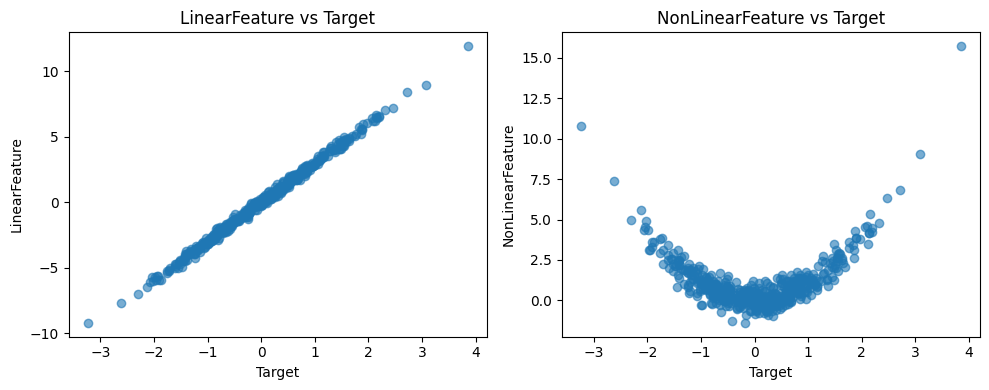

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(df["Target"], df["LinearFeature"], alpha=0.6)
axes[0].set_title("LinearFeature vs Target")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("LinearFeature")

axes[1].scatter(df["Target"], df["NonLinearFeature"], alpha=0.6)
axes[1].set_title("NonLinearFeature vs Target")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("NonLinearFeature")

plt.tight_layout()
plt.show()

# DESEQUILIBRIO DE LAS CLASES

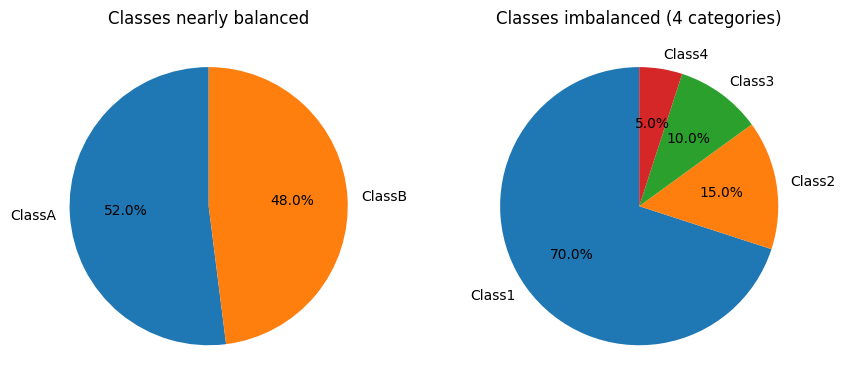

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de clases
balanced = np.array([260, 240])           # dos clases casi equilibradas (no 50/50 exacto)
imbalanced = np.array([700, 150, 100, 50])  # cuatro clases muy desequilibradas

labels_bal = ["ClassA", "ClassB"]
labels_imb = ["Class1", "Class2", "Class3", "Class4"]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Gráfico casi equilibrado
axes[0].pie(balanced, labels=labels_bal, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Classes nearly balanced")

# Gráfico desequilibrado con cuatro clases
axes[1].pie(imbalanced, labels=labels_imb, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Classes imbalanced (4 categories)")

plt.tight_layout()
plt.show()
